
# **🛒 Retail Store Inventory Demand Forecasting using XGBoost + Prophet**


# 🧠 Introduction

Retail businesses rely heavily on accurate demand forecasting to optimize inventory, pricing, and supply chain decisions.

In this notebook, we build a hybrid deep learning model combining a Transformer network and XGBoost, leveraging both temporal dependencies and tree-based feature learning.


This project demonstrates:

✅ Real-world feature engineering (lag, rolling stats, time features)

✅ Transformer architecture for temporal feature extraction

✅ Hybrid stacking with XGBoost for residual correction

✅ Clear evaluation and visualizations


# 📦 Step 1: Import Libraries & Load Dataset

We start by importing all the required packages for:


Data preprocessing


Model building (TensorFlow, XGBoost, LightGBM)


Visualization (Matplotlib, Seaborn)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, MultiHeadAttention, LayerNormalization, Add, GlobalAveragePooling1D
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import pickle # Import pickle
import joblib # Import joblib


# 🧾 Step 2: Data Loading and Initial Exploration


We load the dataset and perform basic feature exploration.

In [2]:
# Load the dataset
df = pd.read_csv('/content/retail_store_inventory.csv')


In [3]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [4]:
# Checking the shape and data types of the df

print(df.shape)
print(df.info())

(73100, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory


**This dataset contains:**

Store & Product information

Inventory and sales data

Demand forecast values

Temporal details (Date, Holiday, Discount, etc.)

Additionally, the dataset is currently complete with no missing values



# 🧹 Step 3: Feature Engineering


We extract time-based features, generate lag features, and compute rolling statistics to capture historical patterns.

In [5]:
# --- Data Preprocessing and Feature Engineering ---
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Extract time-based features
df['year'] = df['Date'].dt.year # Extract the year from the date
df['month'] = df['Date'].dt.month # Extract the month from the date
df['day'] = df['Date'].dt.day # Extract the day from the day
df['dayofweek'] = df['Date'].dt.dayofweek # Extract the day of the week (Monday=0, Sunday=6)
df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int) # Extract the week of the year

# Sort the DataFrame by 'Date'
df = df.sort_values(by='Date').reset_index(drop=True)

# 🔁 Lag & Rolling Features


Creating granular features using lag and rolling windows for multiple metrics such as Inventory Level, Units Sold, and Price.

In [6]:
# Create lag features
lag_period = 7 # Define the number of previous days to look back for lag features
for col in ['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price']:
    # Create lag features for each specified column, grouped by Store ID and Product ID
    df[f'{col}_lag_{lag_period}'] = df.groupby(['Store ID', 'Product ID'])[col].shift(lag_period)

# Create rolling window features (mean and std)
rolling_window = 7 # Define the size of the rolling window
for col in ['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price']:
    # Calculate rolling mean for each specified column, grouped by Store ID and Product ID
    df[f'{col}_rolling_mean_{rolling_window}'] = df.groupby(['Store ID', 'Product ID'])[col].rolling(window=rolling_window).mean().reset_index(drop=True)
    # Calculate rolling standard deviation for each specified column, grouped by Store ID and Product ID
    df[f'{col}_rolling_std_{rolling_window}'] = df.groupby(['Store ID', 'Product ID'])[col].rolling(window=rolling_window).std().reset_index(drop=True)

# Handle potential missing values created by lag and rolling window features (fill with 0)
df = df.fillna(0)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Date                            73100 non-null  datetime64[ns]
 1   Store ID                        73100 non-null  object        
 2   Product ID                      73100 non-null  object        
 3   Category                        73100 non-null  object        
 4   Region                          73100 non-null  object        
 5   Inventory Level                 73100 non-null  int64         
 6   Units Sold                      73100 non-null  int64         
 7   Units Ordered                   73100 non-null  int64         
 8   Demand Forecast                 73100 non-null  float64       
 9   Price                           73100 non-null  float64       
 10  Discount                        73100 non-null  int64         
 11  We

***This ensures the model sees past behavior trends for each store and product.****

## Evaluating XGBoost for Forecasting Units Sold

In [8]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy().sort_values("Date").reset_index(drop=True)

# Encode categorical columns
cat_cols = ["Store ID", "Product ID", "Category", "Region",
            "Weather Condition", "Seasonality"]

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le   # store encoders if needed later

In [9]:
# Splitting the data for training and testing

cutoff_date = df_model["Date"].max() - pd.Timedelta(days=90)

train = df_model[df_model["Date"] <= cutoff_date].copy()
test  = df_model[df_model["Date"] > cutoff_date].copy()


In [10]:
# Creating our variables for modeling based on "Units Sold"

target = "Units Sold"

drop_cols = ["Date", target]

# X matrices
X_train = train.drop(columns=drop_cols)
X_test = test.drop(columns=drop_cols)

# y vectors
y_train = train[target]
y_test = test[target]


In [11]:
# Building and Training the XGBoost model

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist"   # efficient
)

xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [12]:
# Evaluating our model

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("XGBoost RMSE:", rmse)
print("XGBoost MAE:", mae)


XGBoost RMSE: 8.76798427335345
XGBoost MAE: 7.416592121124268


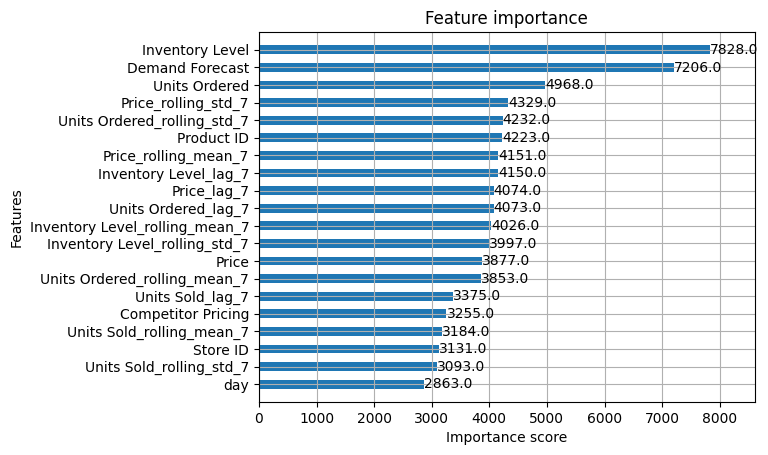

In [13]:
# Observing our key features from the model

import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(xgb_model, max_num_features=20, height=0.5)
plt.show()


Stores: [0 1 2 3 4]
Processing Store: 0 with Products: [0 1]


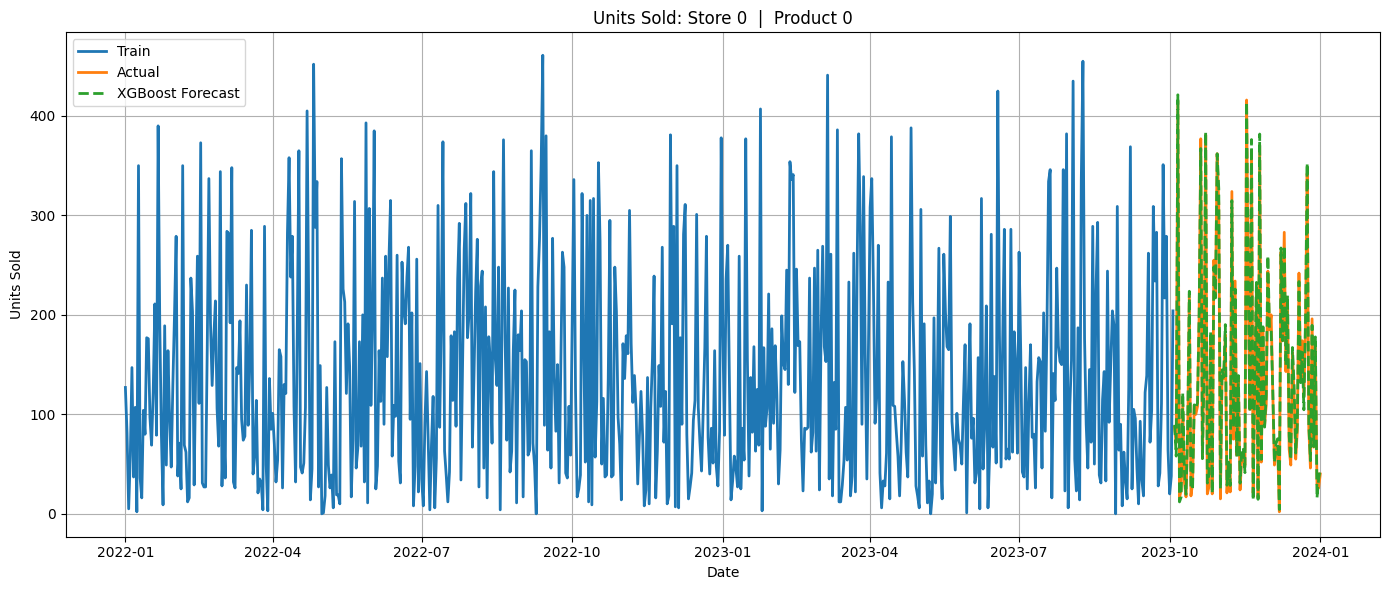

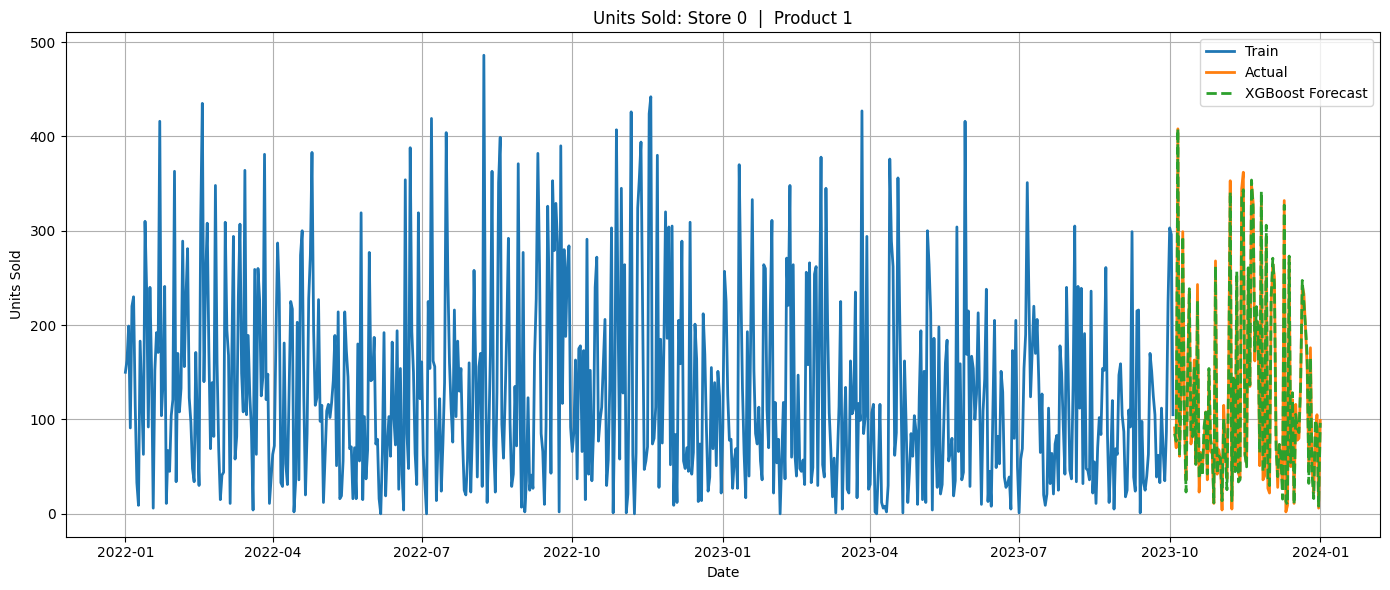

Processing Store: 1 with Products: [3 0]


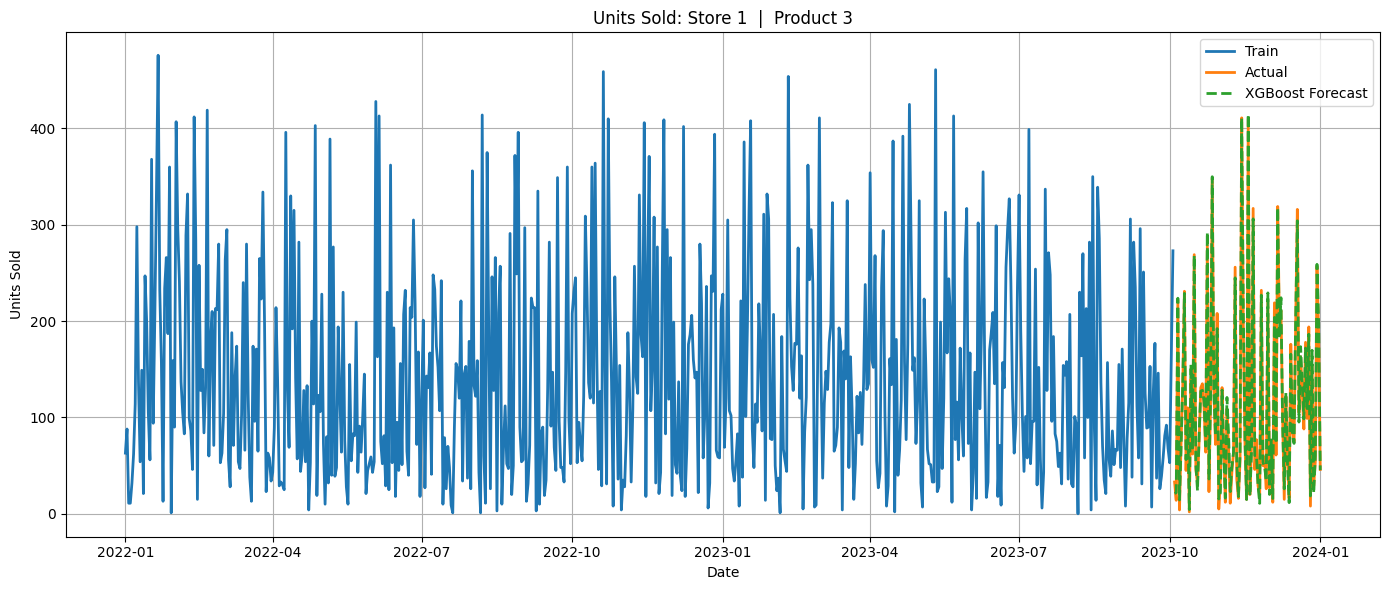

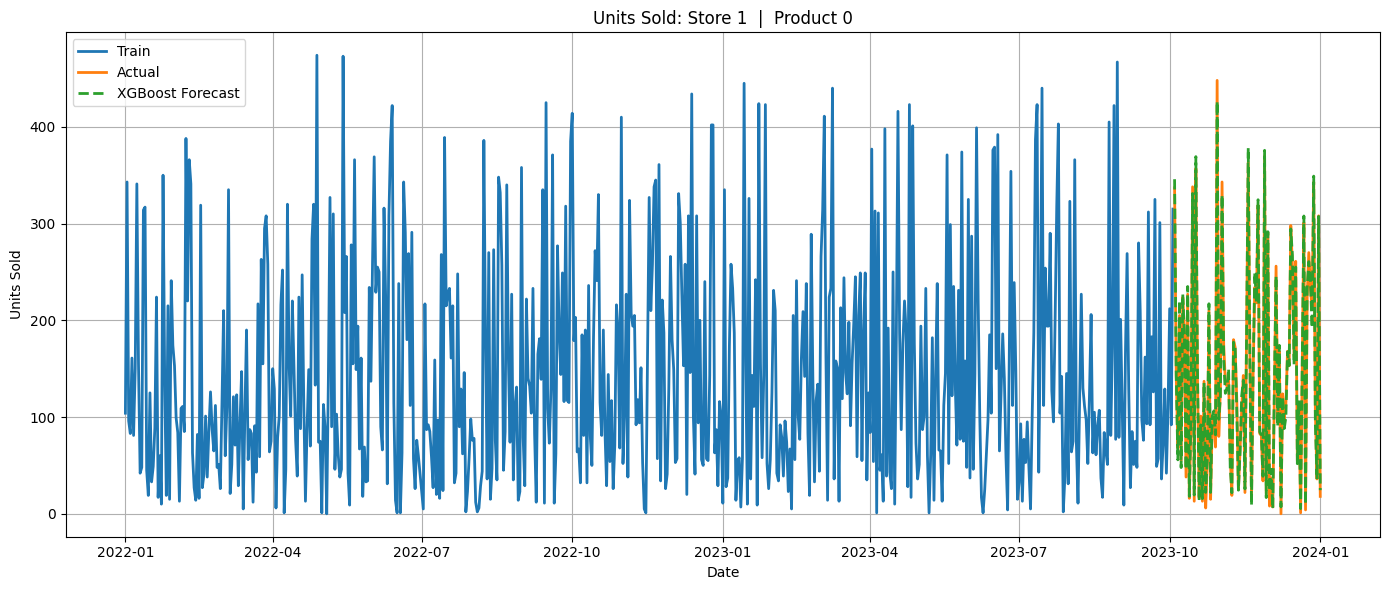

Processing Store: 2 with Products: [9 7]


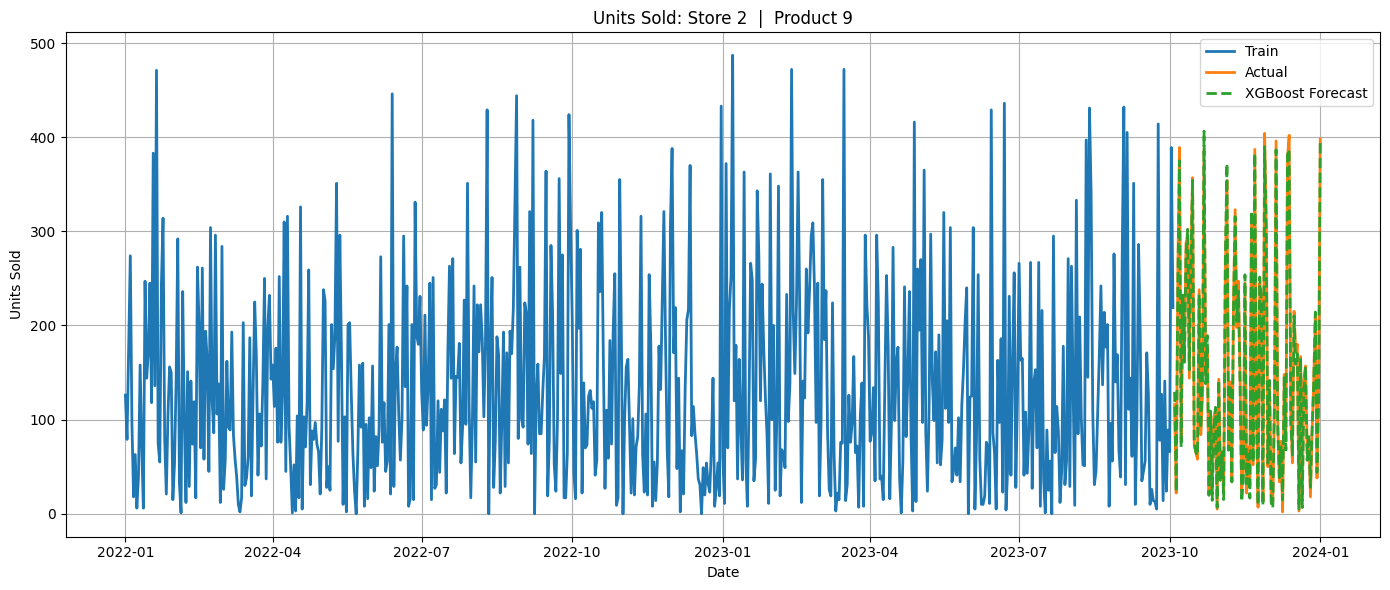

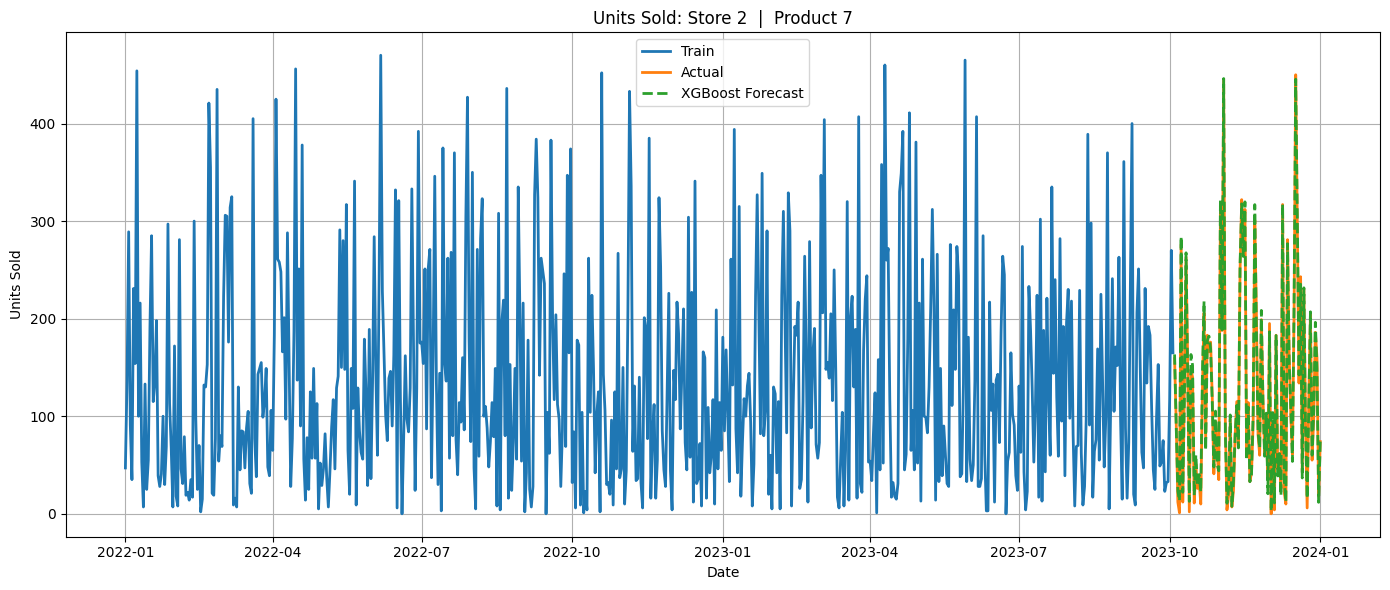

Processing Store: 3 with Products: [14 13]


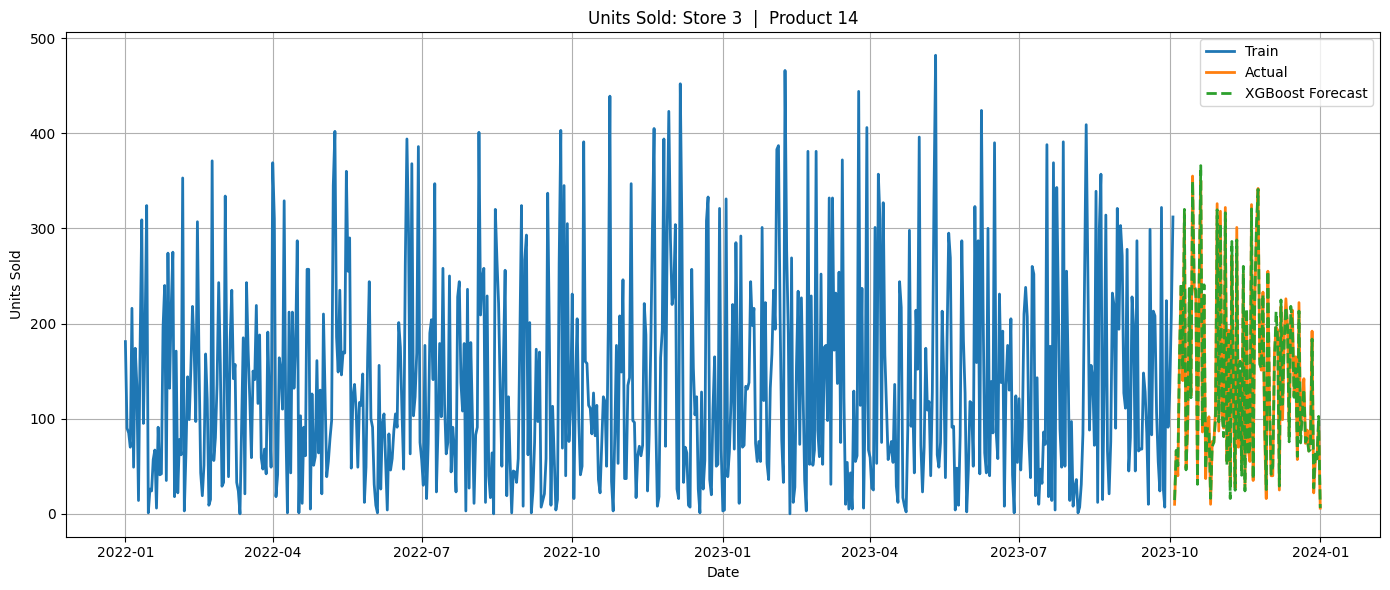

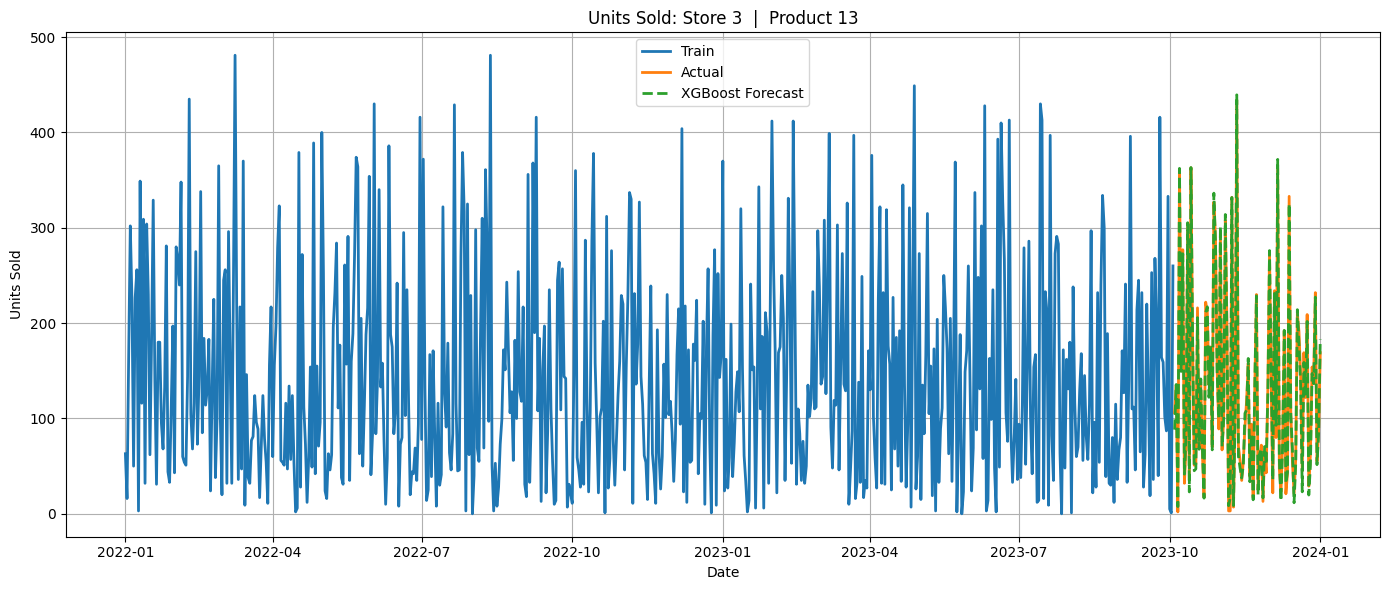

Processing Store: 4 with Products: [8 0]


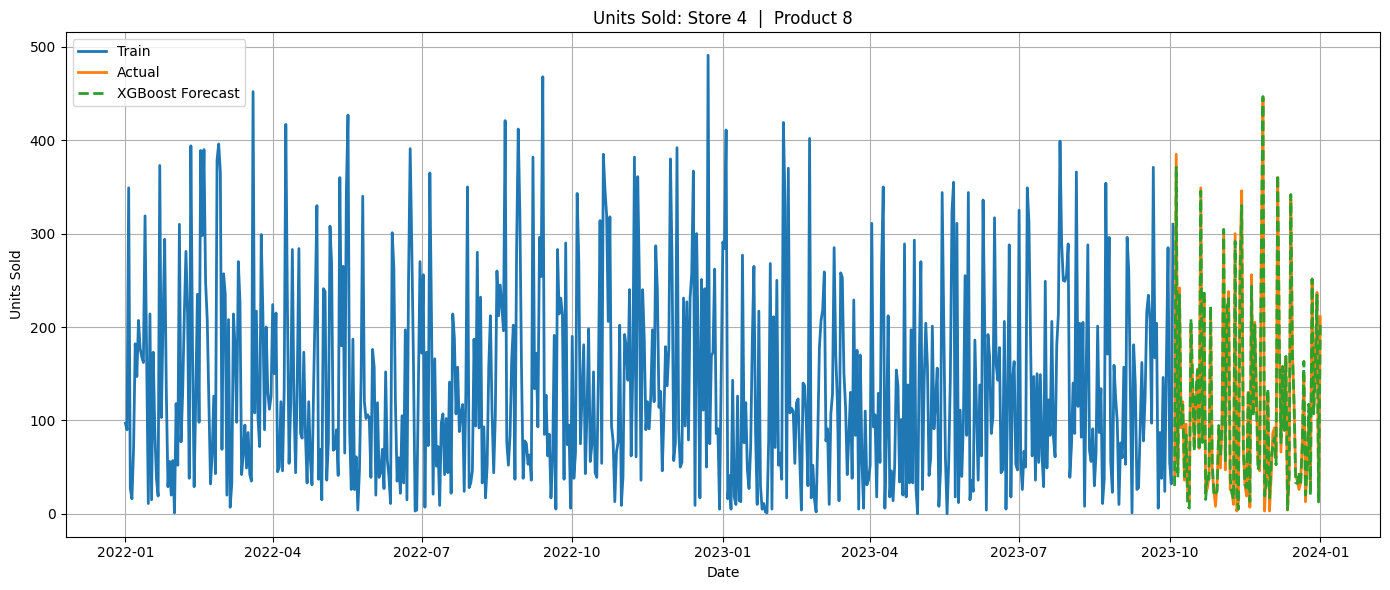

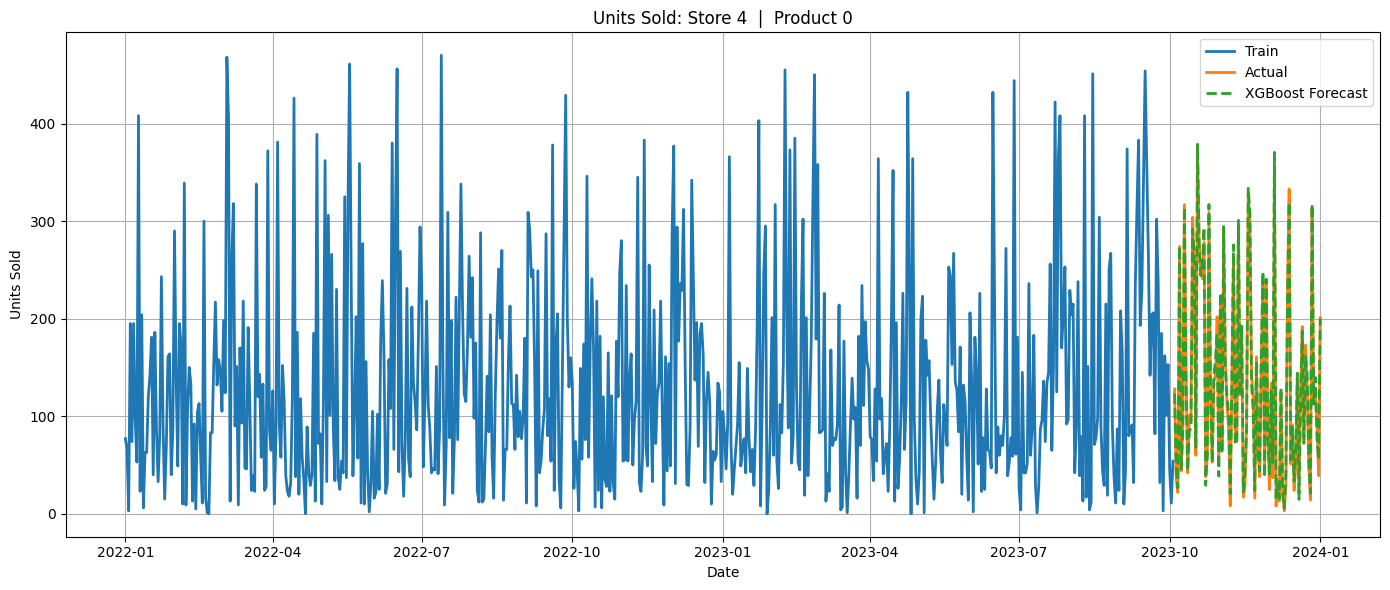

In [14]:
# Use only the correctly encoded dataframe
df_full = df_model.copy()

store_ids = df_full["Store ID"].unique()

print("Stores:", store_ids)

for store in store_ids:
    # Get product IDs for the current store and take the first 2
    products_for_store = df_full[df_full["Store ID"] == store]["Product ID"].unique()
    selected_product_ids = products_for_store[:2] # Take the first 2 product IDs
    print(f"Processing Store: {store} with Products: {selected_product_ids}")

    for product in selected_product_ids:

        # ---- Filter to store + product ----
        df_pair = df_full[(df_full["Store ID"] == store) &
                          (df_full["Product ID"] == product)].copy()

        if df_pair.empty:
            print(f"Skipping {store} {product} — no data")
            continue

        # Sort chronologically
        df_pair = df_pair.sort_values("Date")

        # ---- Time-based split ----
        cutoff_date = df_pair["Date"].max() - pd.Timedelta(days=90)
        train_pair = df_pair[df_pair["Date"] <= cutoff_date]
        test_pair  = df_pair[df_pair["Date"] > cutoff_date]

        # Ensure we have both train and test points
        if len(train_pair) == 0 or len(test_pair) == 0:
            print(f"Skipping {store} {product} — insufficient data")
            continue

        # ---- Extract X and y ----
        drop_cols = ["Date", "Units Sold"]

        X_train = train_pair.drop(columns=drop_cols)
        X_test = test_pair.drop(columns=drop_cols)

        y_train = train_pair["Units Sold"].values
        y_test = test_pair["Units Sold"].values

        # ---- Predict ----
        y_pred = xgb_model.predict(X_test)

        # ---- Plot ----
        plt.figure(figsize=(14, 6))
        plt.plot(train_pair["Date"], y_train, label="Train", linewidth=2)
        plt.plot(test_pair["Date"], y_test, label="Actual", linewidth=2)
        plt.plot(test_pair["Date"], y_pred, label="XGBoost Forecast", linestyle="--", linewidth=2)

        plt.title(f"Units Sold: Store {store}  |  Product {product}")
        plt.xlabel("Date")
        plt.ylabel("Units Sold")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        plt.show()

## Building a Demand Forecast using Prophet

In [15]:
# Building our Prophet Model Function


from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

def forecast_demand(df, store_id, product_id, forecast_days=90, train_fraction=0.8):
    """
    Forecast demand using Prophet for a single Store-Product combination.

    Parameters:
    -----------
    df : pd.DataFrame
        Full dataset with columns: Date, Store ID, Product ID, Demand Forecast
    store_id : str or int
        Store to filter
    product_id : str or int
        Product to filter
    forecast_days : int
        Number of days to forecast into the future
    train_fraction : float
        Fraction of historical data to use for training

    Returns:
    --------
    forecast : pd.DataFrame
        Prophet forecast with yhat, yhat_lower, yhat_upper
    metrics : dict
        Evaluation metrics on the test period (MAPE, RMSE)
    """

    # -----------------------------
    # Filter store/product
    # -----------------------------
    df_sp = df[(df['Store ID'] == store_id) & (df['Product ID'] == product_id)].copy()

    if df_sp.empty:
        raise ValueError(f"No data found for Store {store_id} Product {product_id}")

    df_sp = df_sp.sort_values("Date")

    # -----------------------------
    # Prepare Prophet dataframe
    # -----------------------------
    df_prophet = df_sp.rename(columns={"Date": "ds", "Demand Forecast": "y"})
    df_prophet = df_prophet[["ds", "y"]].copy()

    # -----------------------------
    # Train/test split
    # -----------------------------
    cutoff_idx = int(len(df_prophet) * train_fraction)
    train_df = df_prophet.iloc[:cutoff_idx]
    test_df  = df_prophet.iloc[cutoff_idx:]

    # -----------------------------
    # Fit Prophet model
    # -----------------------------
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.3
    )

    model.fit(train_df)

    # -----------------------------
    # Make predictions for test period
    # -----------------------------
    future = test_df[['ds']].copy()
    forecast = model.predict(future)

    # -----------------------------
    # Clip negative predictions (optional)
    # -----------------------------
    forecast['yhat'] = forecast['yhat'].clip(lower=0)

    # -----------------------------
    # Evaluate
    # -----------------------------
    y_true = test_df['y'].values
    y_pred = forecast['yhat'].values

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    metrics = {"MAPE": mape, "RMSE": rmse}

    return forecast, metrics


{'MAPE': np.float64(262.59059235715836), 'RMSE': np.float64(114.12096054009906)}


/tmp/ipython-input-515660190.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(df[df['Store ID']==store_id][df['Product ID']==product_id]['Date'],
/tmp/ipython-input-515660190.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['Store ID']==store_id][df['Product ID']==product_id]['Demand Forecast'],


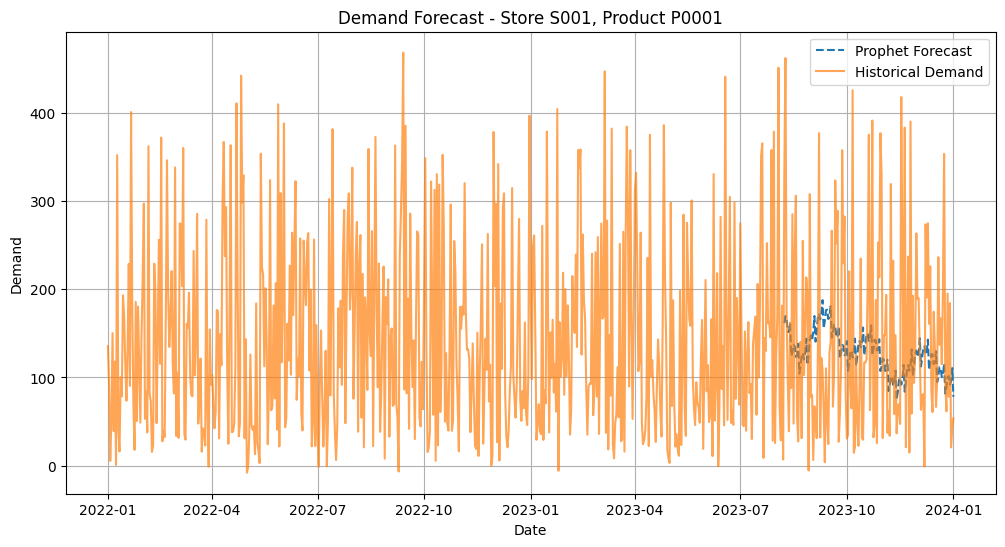

In [16]:
# Forecasting Demand

store_id = 'S001'
product_id = 'P0001'

forecast, metrics = forecast_demand(df, store_id, product_id, forecast_days=90)

print(metrics)

# Plot forecast
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(forecast['ds'], forecast['yhat'], label='Prophet Forecast', linestyle='--')
plt.plot(df[df['Store ID']==store_id][df['Product ID']==product_id]['Date'],
         df[df['Store ID']==store_id][df['Product ID']==product_id]['Demand Forecast'],
         label='Historical Demand', alpha=0.7)
plt.title(f"Demand Forecast - Store {store_id}, Product {product_id}")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)
plt.show()


**The high granularity is a bit beyond what the model can predict at this time**

Lets take a weekly view of the data to improve predictions


In [17]:
# Weekly Demand Forecasting by Product Category


from prophet import Prophet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

def forecast_weekly_demand_store_category(df, store_id, category, forecast_weeks=12,
                                          train_fraction=0.8, regressors=None):
    """
    Forecast weekly demand for a Store × Category combination using Prophet with external regressors.

    Parameters:
    -----------
    df : pd.DataFrame
        Must contain: Date, Store ID, Category, Demand Forecast, and optional regressors
    store_id : str
        Store ID to filter
    category : str
        Category to filter
    forecast_weeks : int
        Number of weeks to forecast
    train_fraction : float
        Fraction of historical data for training
    regressors : list of str
        External regressors to include

    Returns:
    --------
    forecast : pd.DataFrame
        Prophet forecast
    metrics : dict
        RMSE and MAPE on test period
    """

    # -----------------------------
    # Filter store & category
    # -----------------------------
    df_sc = df[(df['Store ID'] == store_id) & (df['Category'] == category)].copy()
    if df_sc.empty:
        raise ValueError(f"No data found for Store {store_id} Category {category}")

    df_sc = df_sc.sort_values("Date")

    # -----------------------------
    # Aggregate weekly
    # -----------------------------
    df_sc['ds'] = pd.to_datetime(df_sc['Date'])
    df_sc = df_sc.set_index('ds')

    weekly_cols = ['Demand Forecast']
    if regressors:
        weekly_cols += regressors

    df_weekly = df_sc[weekly_cols].resample('W-MON').sum().reset_index()
    df_weekly.rename(columns={'Demand Forecast': 'y'}, inplace=True)

    # -----------------------------
    # Train/test split
    # -----------------------------
    cutoff_idx = int(len(df_weekly) * train_fraction)
    train_df = df_weekly.iloc[:cutoff_idx].copy()
    test_df  = df_weekly.iloc[cutoff_idx:].copy()

    # -----------------------------
    # Scale regressors
    # -----------------------------
    if regressors:
        scaler = StandardScaler()
        train_df[regressors] = scaler.fit_transform(train_df[regressors])
        test_df[regressors] = scaler.transform(test_df[regressors])

    # -----------------------------
    # Prophet model
    # -----------------------------
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.3
    )

    # Monthly seasonality
    model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

    # Add external regressors
    if regressors:
        for reg in regressors:
            model.add_regressor(reg)

    model.fit(train_df)

    # -----------------------------
    # Forecast test period
    # -----------------------------
    future = test_df[['ds'] + (regressors if regressors else [])].copy()
    forecast = model.predict(future)
    forecast['yhat'] = forecast['yhat'].clip(lower=0)

    # -----------------------------
    # Metrics
    # -----------------------------
    y_true = test_df['y'].values
    y_pred = forecast['yhat'].values
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1, y_true))) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    metrics = {'MAPE': mape, 'RMSE': rmse}

    return forecast, metrics, test_df


{'MAPE': np.float64(11.993619924783127), 'RMSE': np.float64(516.6578502985758)}


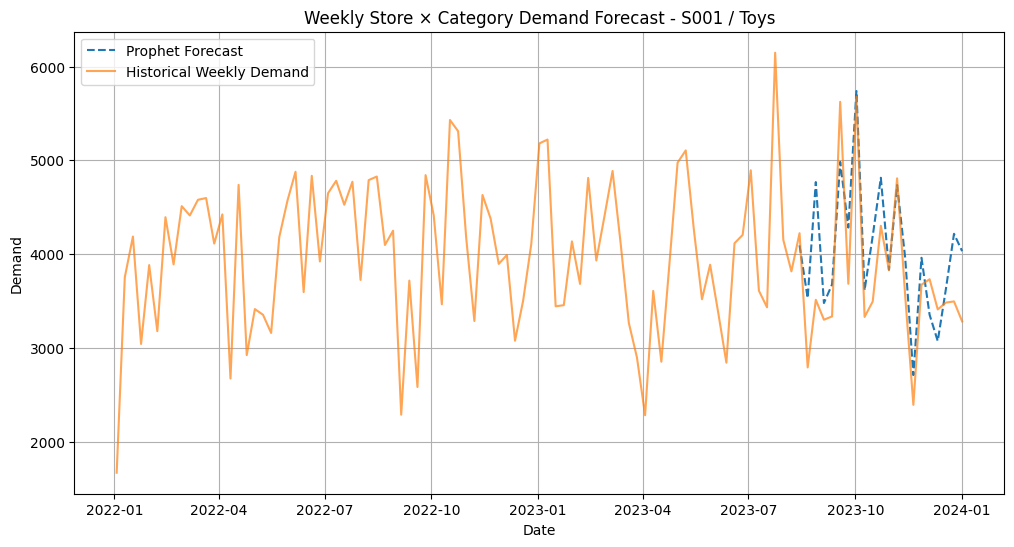

In [18]:
# Define regressors
regressors = ['Inventory Level', 'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing']

store_id = 'S001'
category = 'Toys'

forecast, metrics, test_df = forecast_weekly_demand_store_category(
    df, store_id, category,
    forecast_weeks=12,
    train_fraction=0.8,
    regressors=regressors
)

print(metrics)

# Plot forecast
import matplotlib.pyplot as plt

weekly_hist = df[(df['Store ID']==store_id) & (df['Category']==category)]
weekly_hist = weekly_hist.resample('W-MON', on='Date')['Demand Forecast'].sum()

plt.figure(figsize=(12,6))
plt.plot(forecast['ds'], forecast['yhat'], label='Prophet Forecast', linestyle='--')
plt.plot(weekly_hist.index, weekly_hist.values, label='Historical Weekly Demand', alpha=0.7)
plt.title(f"Weekly Store × Category Demand Forecast - {store_id} / {category}")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
# Plotting our Predicted vs Actual Demand


def plot_predicted_vs_actual_store_category(df, store_id, category, forecast, train_fraction=0.8):
    """
    Reconstructs the test set and plots actual vs predicted weekly demand.
    """

    # -----------------------------
    # Rebuild weekly store-category dataset
    # -----------------------------
    df_sc = df[(df['Store ID'] == store_id) & (df['Category'] == category)].copy()
    df_sc = df_sc.sort_values("Date")

    df_sc['ds'] = pd.to_datetime(df_sc['Date'])
    df_sc = df_sc.set_index('ds')

    df_weekly = df_sc[['Demand Forecast']].resample('W-MON').sum().reset_index()
    df_weekly.rename(columns={'Demand Forecast': 'y'}, inplace=True)

    # -----------------------------
    # Rebuild test set split
    # -----------------------------
    cutoff_idx = int(len(df_weekly) * train_fraction)
    test_df = df_weekly.iloc[cutoff_idx:].copy()

    # -----------------------------
    # Extract true & predicted
    # -----------------------------
    y_true = test_df['y'].values
    y_pred = forecast['yhat'].values

    # -----------------------------
    # Scatter Plot
    # -----------------------------
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.6)

    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Prediction")

    plt.title(f"Predicted vs Actual Weekly Demand\nStore: {store_id} | Category: {category}")
    plt.xlabel("Actual Weekly Demand")
    plt.ylabel("Predicted Weekly Demand")

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

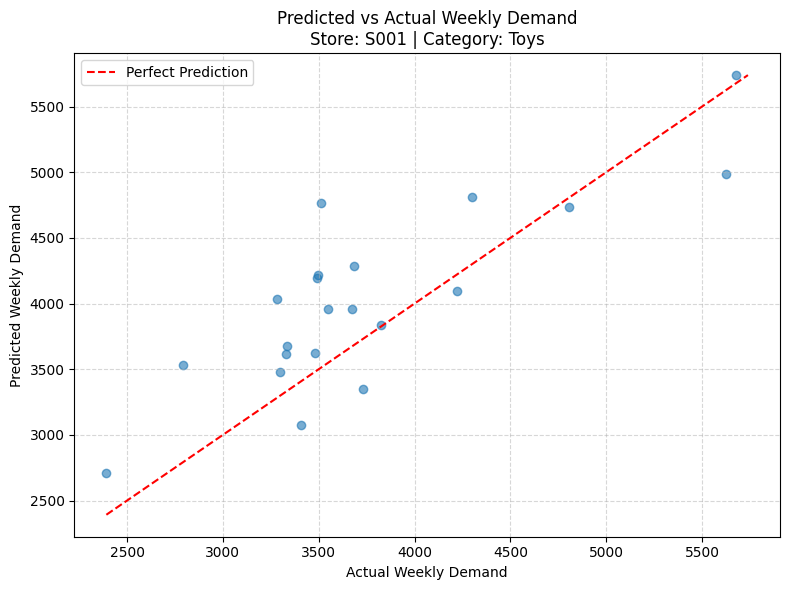

In [20]:
# Representative plot of Demand Predictions for Toys vs Actual Demand

plot_predicted_vs_actual_store_category(df, "S001", "Toys", forecast)


## Compiling our Dashboard Components For Store ID = S001

In [21]:
# Forecasting for all Categories

store_id = "S001"
categories = df[df["Store ID"] == store_id]["Category"].unique()

results = {}

for cat in categories:
    try:
        forecast, metrics, test_df = forecast_weekly_demand_store_category(
            df,
            store_id=store_id,
            category=cat,
            regressors=['Inventory Level', 'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing']  # example
        )
        results[cat] = {"forecast": forecast, "metrics": metrics, "test_df": test_df}
    except Exception as e:
        print(f"Skipping {cat}: {e}")


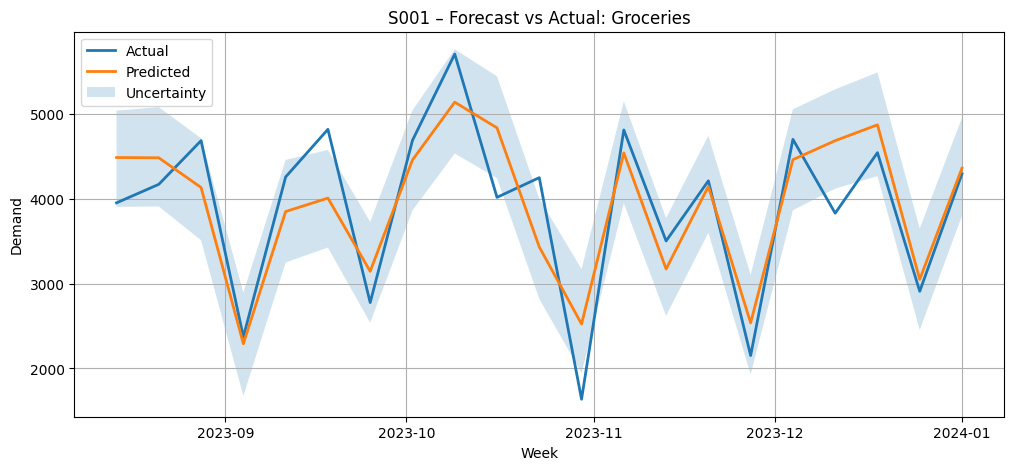

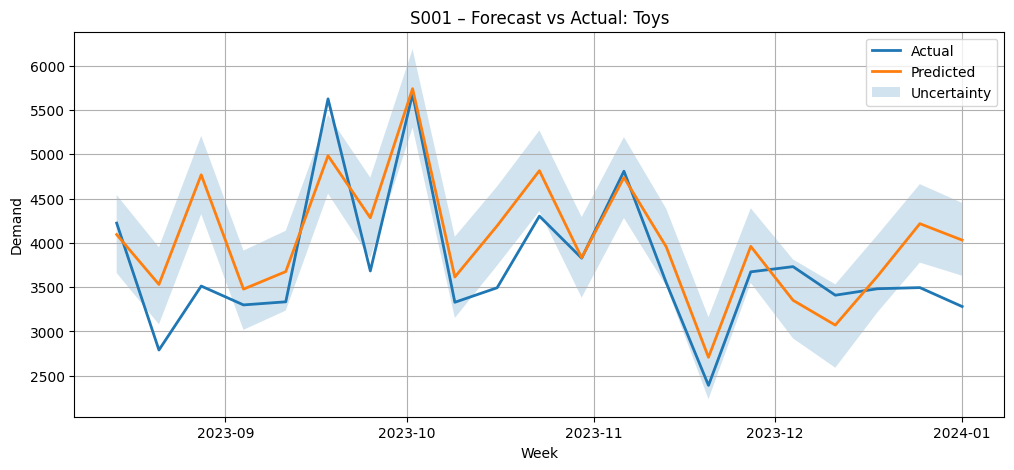

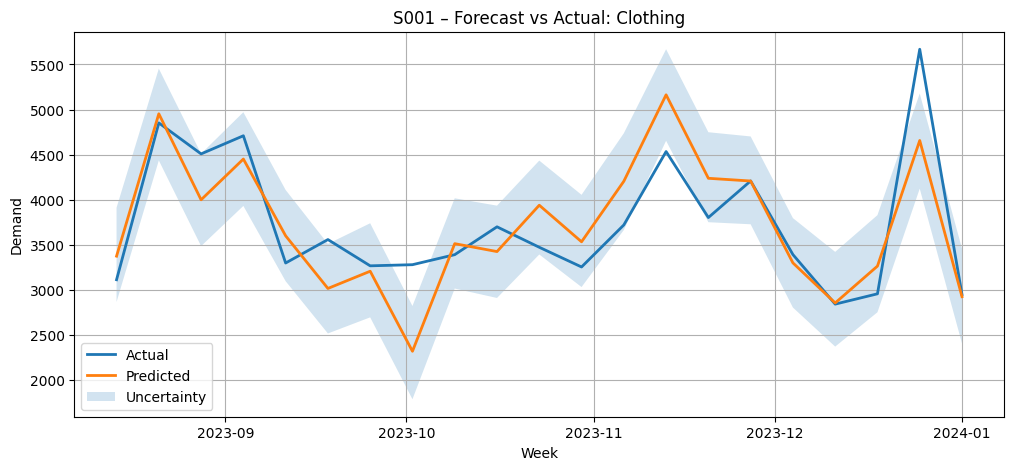

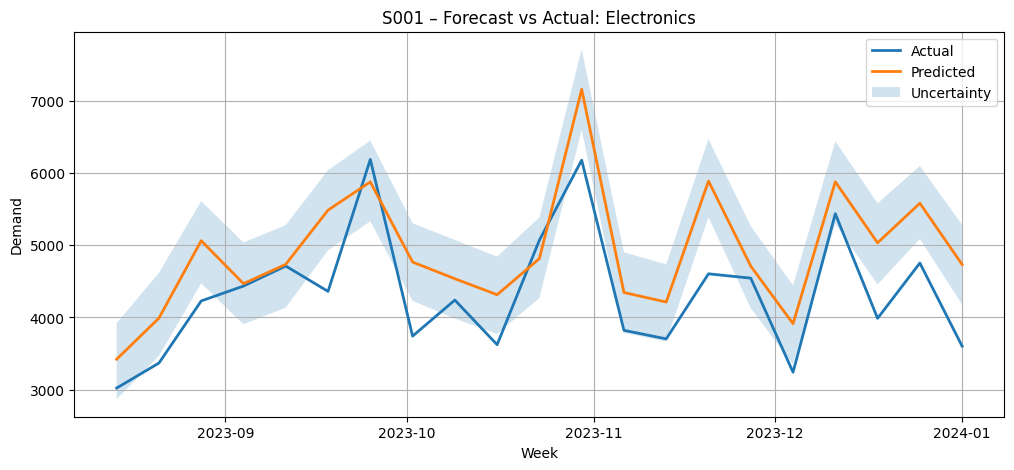

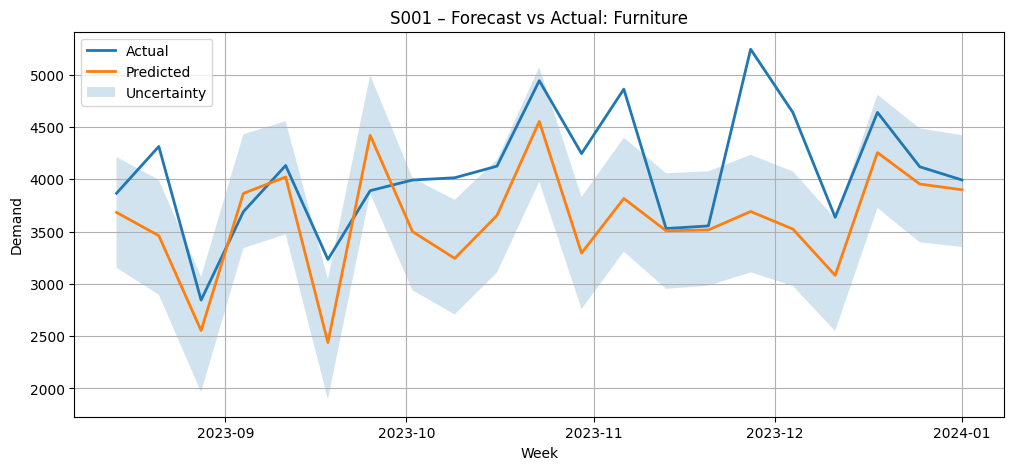

In [22]:
# Plotting our Predictions for S001

import matplotlib.pyplot as plt

for cat, data in results.items():
    forecast = data["forecast"]
    test_df = data["test_df"]

    plt.figure(figsize=(12,5))
    plt.plot(test_df["ds"], test_df["y"], label="Actual", linewidth=2)
    plt.plot(forecast["ds"], forecast["yhat"], label="Predicted", linewidth=2)
    plt.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"],
                     alpha=0.2, label="Uncertainty")

    plt.title(f"S001 – Forecast vs Actual: {cat}")
    plt.xlabel("Week")
    plt.ylabel("Demand")
    plt.legend()
    plt.grid(True)
    plt.show()


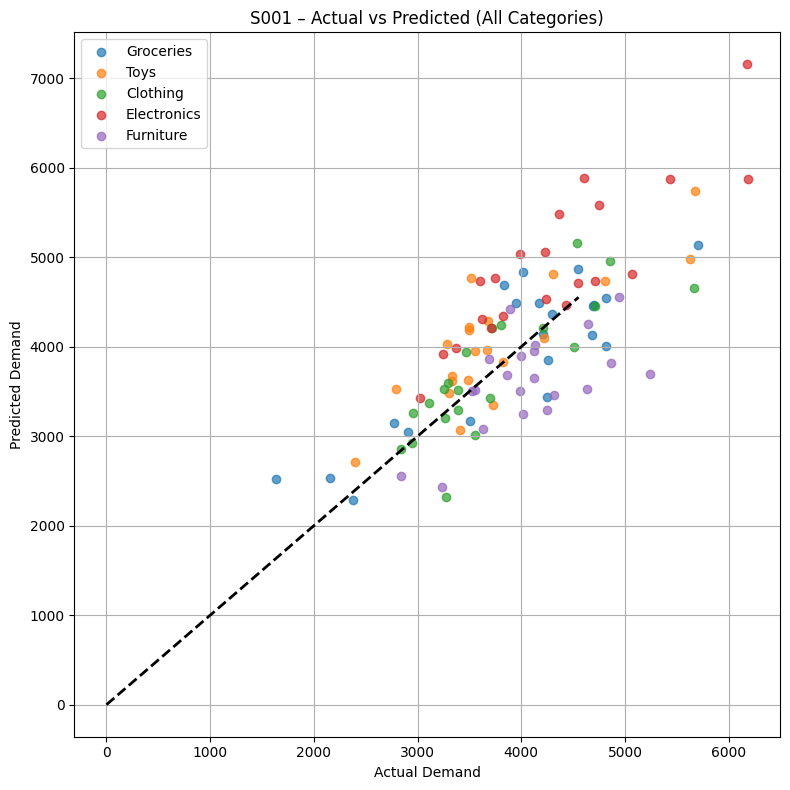

In [23]:
# Evaluating our Predicted vs Actual Forecasting Demand


plt.figure(figsize=(8,8))

for cat, data in results.items():
    test_df = data["test_df"]
    forecast = data["forecast"]

    plt.scatter(test_df["y"], forecast["yhat"], label=cat, alpha=0.7)

# Reference line
max_val = max(df["Demand Forecast"].max(), forecast["yhat"].max())
plt.plot([0, max_val], [0, max_val], "k--", lw=2)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("S001 – Actual vs Predicted (All Categories)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


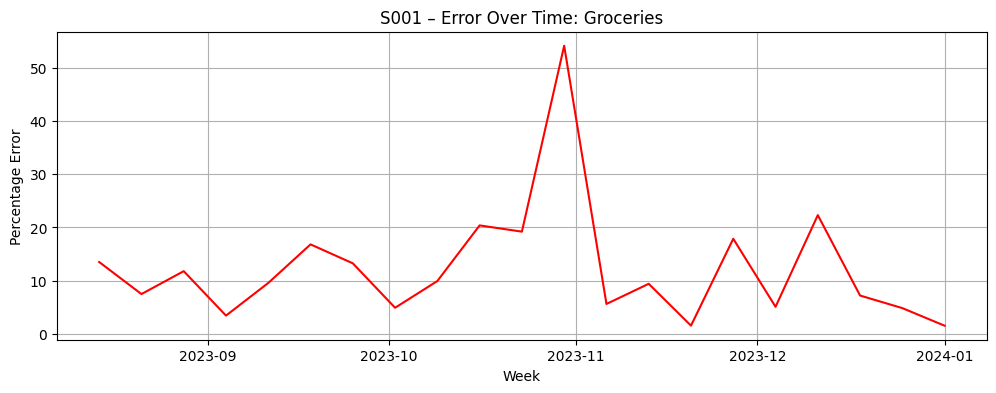

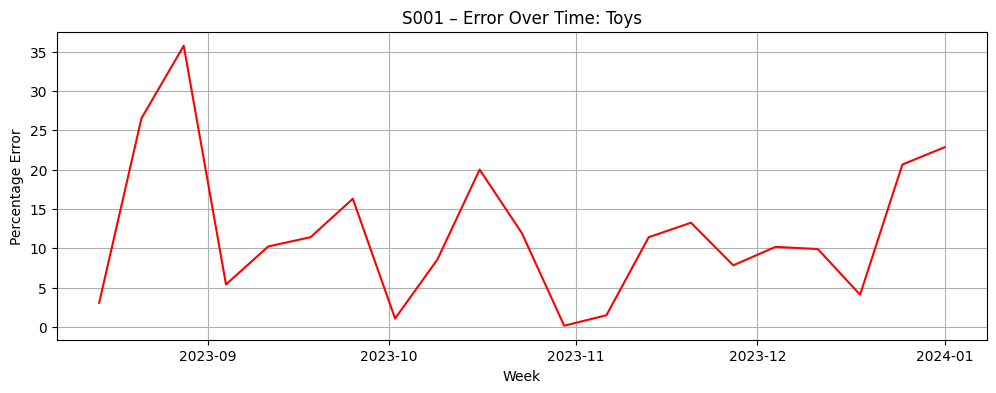

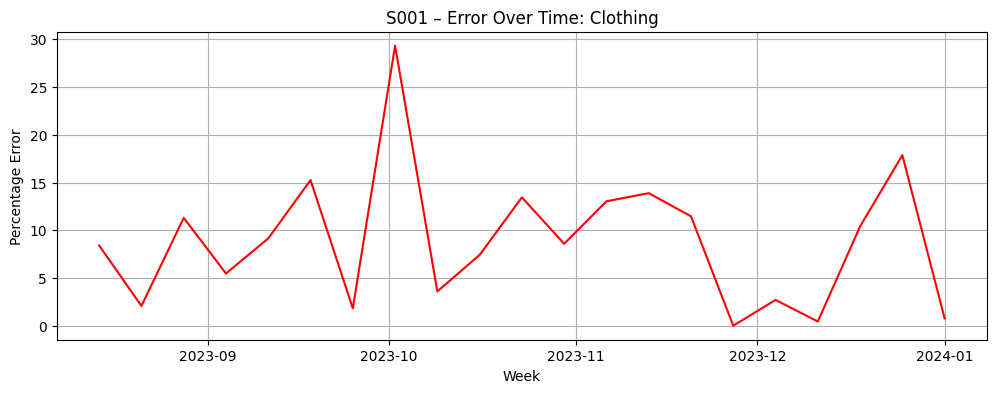

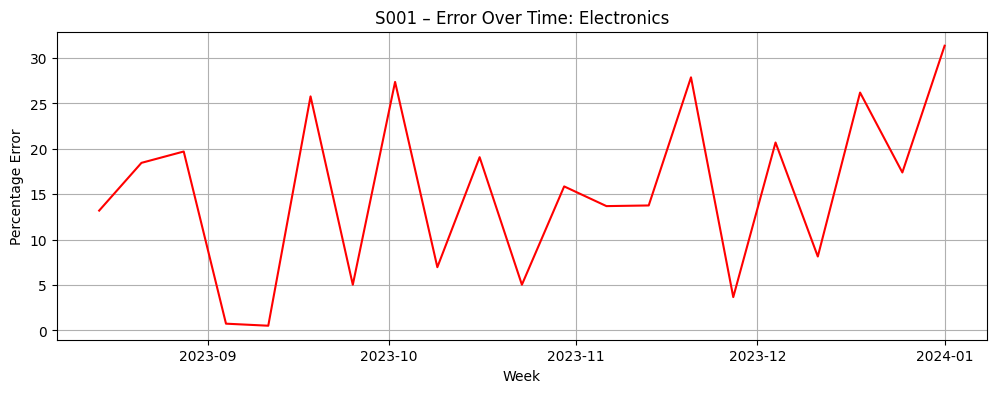

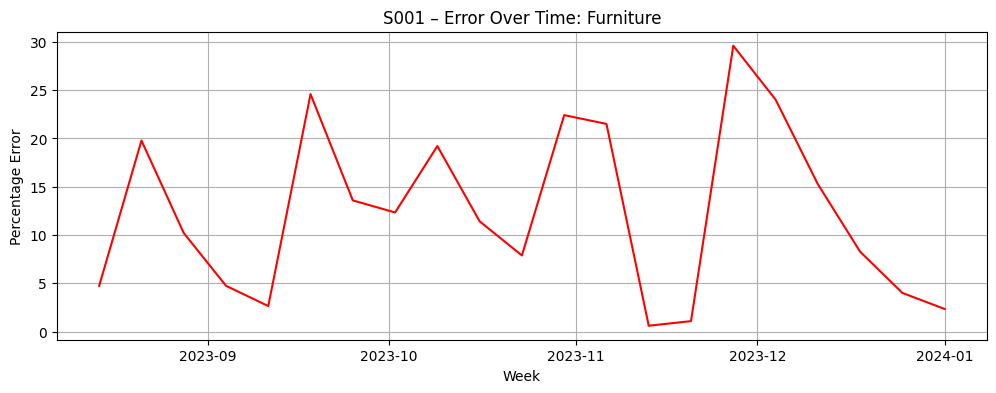

In [24]:
# Looking at our Error as a function of Time

for cat, data in results.items():
    test_df = data["test_df"]
    forecast = data["forecast"]

    # Ensure 'ds' column is datetime for merging
    test_df['ds'] = pd.to_datetime(test_df['ds'])
    forecast['ds'] = pd.to_datetime(forecast['ds'])

    # Merge forecast with actuals on 'ds' to ensure alignment
    # This handles cases where forecast or test_df might have missing dates
    # or slightly different date ranges, ensuring 'y' and 'yhat' are aligned by date.
    aligned_df = pd.merge(test_df[['ds', 'y']], forecast[['ds', 'yhat']], on='ds', how='inner')

    # If the merge results in an empty DataFrame, skip this category
    if aligned_df.empty:
        print(f"Skipping error plot for {cat}: No common dates for alignment.")
        continue

    # Now calculate absolute error and percentage error on the aligned data
    ae = abs(aligned_df["y"] - aligned_df["yhat"])
    # Handle division by zero for y_true = 0 by replacing with 1
    ape = ae / np.where(aligned_df["y"] == 0, 1, aligned_df["y"]) * 100

    plt.figure(figsize=(12,4))
    plt.plot(aligned_df["ds"], ape, label="APE (%)", color="red") # Use aligned_df["ds"]
    plt.title(f"S001 – Error Over Time: {cat}")
    plt.xlabel("Week")
    plt.ylabel("Percentage Error")
    plt.grid(True)
    plt.show()


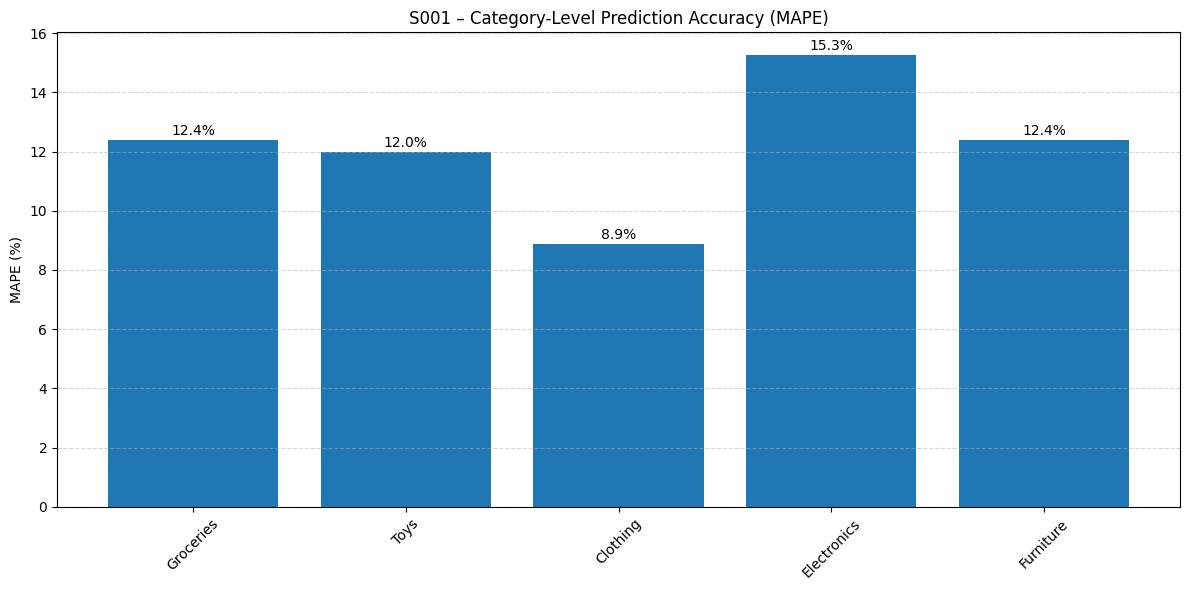

In [25]:
# Comparing our metrics across Categories


# Build metrics DataFrame
metric_df = pd.DataFrame([
    {"Category": cat, "MAPE": data["metrics"]["MAPE"], "RMSE": data["metrics"]["RMSE"]}
    for cat, data in results.items()
])

# Plot MAPE as bar chart
plt.figure(figsize=(12,6))
bars = plt.bar(metric_df["Category"], metric_df["MAPE"])

plt.title("S001 – Category-Level Prediction Accuracy (MAPE)")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# --- Add labels above bars ---
for bar, value in zip(bars, metric_df["MAPE"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (max(metric_df["MAPE"]) * 0.02),   # small vertical offset
        f"{value:.1f}%",                             # one decimal place
        ha='center', va='center', fontsize=10
    )

plt.tight_layout()
plt.show()

In [26]:
# Building The Dashboard with Plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# Build metrics table
metric_df = pd.DataFrame([
    {"Category": cat,
     "MAPE": data["metrics"]["MAPE"],
     "RMSE": data["metrics"]["RMSE"]}
    for cat, data in results.items()
])

categories = metric_df["Category"].tolist()

# ----------------------------------------------
# Create subplots layout
# ----------------------------------------------
fig = make_subplots(
    rows=1, cols=3,
    specs=[[{"type": "bar"}, {"type": "scatter"}, {"type": "scatter"}]],
    column_widths=[0.3, 0.35, 0.35],
    subplot_titles=[
        "MAPE by Category",
        "Weekly Forecast (Actual vs Predicted)",
        "Predicted vs Actual Scatter"
    ]
)

# ----------------------------------------------
# 1️⃣ ADD MAPE BAR CHART
# ----------------------------------------------
fig.add_trace(
    go.Bar(
        x=metric_df["Category"],
        y=metric_df["MAPE"],
        text=[f"{v:.1f}%" for v in metric_df["MAPE"]],
        textposition="outside",
        name="MAPE"
    ),
    row=1, col=1
)

# --------------------------
# Build traces for each category
# --------------------------
forecast_traces = []
scatter_traces = []

for cat in categories:
    forecast = results[cat]["forecast"]
    test_df = results[cat]["test_df"]

    # Forecast time series (hidden initially)
    forecast_traces.append(
        go.Scatter(
            x=test_df["ds"],
            y=test_df["y"],
            mode="lines+markers",
            name="Actual Demand",
            visible=False
        )
    )
    forecast_traces.append(
        go.Scatter(
            x=forecast["ds"],
            y=forecast["yhat"],
            mode="lines+markers",
            name="Predicted Demand",
            line=dict(dash="dash"),
            visible=False
        )
    )

    # Scatter plot (hidden initially)
    scatter_traces.append(
        go.Scatter(
            x=test_df["y"],
            y=forecast["yhat"],
            mode="markers",
            name="Actual vs Predicted",
            visible=False,
            marker=dict(size=8, opacity=0.7)
        )
    )
    scatter_traces.append(
        go.Scatter(
            x=test_df["y"],
            y=test_df["y"],
            mode="lines",
            name="Perfect Prediction",
            line=dict(dash="dot"),
            visible=False
        )
    )

# Add all the traces to figure
for tr in forecast_traces:
    fig.add_trace(tr, row=1, col=2)
for tr in scatter_traces:
    fig.add_trace(tr, row=1, col=3)

# ----------------------------------------------
# Default selection = first category
# ----------------------------------------------
for i in range(4):  # 2 traces per subplot
    fig.data[i+1].visible = True  # make default category visible

# ----------------------------------------------
# Build dropdown logic
# ----------------------------------------------
dropdown_buttons = []

for idx, cat in enumerate(categories):
    # Set all traces to False by default
    visibility = [True]  # bar chart always visible

    # number of categories × 2 traces (actual + forecast)
    for i in range(len(categories)):
        visibility.extend([False, False])  # forecast panel
    for i in range(len(categories)):
        visibility.extend([False, False])  # scatter panel

    # Turn ON just the 2 + 2 traces for this category
    forecast_start = 1 + idx * 2
    scatter_start = 1 + (len(categories) * 2) + idx * 2

    visibility[forecast_start] = True
    visibility[forecast_start + 1] = True
    visibility[scatter_start] = True
    visibility[scatter_start + 1] = True

    dropdown_buttons.append(
        dict(
            label=cat,
            method="update",
            args=[{"visible": visibility},
                  {"title": f"Store S001 – Forecast Dashboard (Category: {cat})"}]
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            buttons=dropdown_buttons,
            direction="down",
            showactive=True,
            x=0.50, y=1.18,
            xanchor="center",
        )
    ],
    title=f"Store S001 – Forecast Dashboard (Category: {categories[0]})",
    height=600,
    margin=dict(l=40, r=40, t=100, b=40),
    showlegend=False
)

# AXES LABELS
fig.update_xaxes(title="Category", row=1, col=1)
fig.update_yaxes(title="MAPE (%)", row=1, col=1)

fig.update_xaxes(title="Date", row=1, col=2)
fig.update_yaxes(title="Demand", row=1, col=2)

fig.update_xaxes(title="Actual", row=1, col=3)
fig.update_yaxes(title="Predicted", row=1, col=3)

fig.show()

Insights & Takeaways

* XGBoost was effectively used to explore product level unit sales broken down by each store

* Prophet was successfully utilized to forecast demand by category for any given store in the dataset with relatively high accuracy

* We see clear seasonal trends with consumer good categories (i.e. toys, electronics) but far flatter demand for staple items such as groceries

* A general spike in demand is observed in November across the categorical board, and therefore each store should procure adequate inventory for the Q4 shopping rush.
